# Quotes, handles and scenario risk

Update a market quote, relink a curve and revalue the same bond without rebuilding its contract.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A trader changes a rate and expects every dependent instrument to update. QuantLib's observable quotes and handles connect that workflow: `SimpleQuote` supplies a rate, `FlatForward` observes it, `RelinkableYieldTermStructureHandle` identifies the curve, and `DiscountingBondEngine` values the contract.

The example fixes a two-year zero-coupon bond, face 100 and zero settlement days. Its flat continuously compounded rate starts at 3.5% with Actual/365 Fixed. Quote shocks change the same live bond's value. The notebook compares each result against $100e^{-rT}$, checks signed zero-rate DV01 against $-T PV\times10^{-4}$, restores the quote after the sweep, and relinks the handle to an independently created 4.5% curve before restoring the original link.

The scenario object is the continuously compounded flat zero rate, not an OIS market-quote strip. That distinction determines what the reported sensitivity means. The [bond-risk chapter](../05-bond-risk/README.md) supplies quote-bucket risk with complete curve rebuilds. Fixed reference dates make these instantaneous scenarios: no carry, roll-down or settlement-date movement is included.

Both quote restoration and handle restoration are checked. This is useful for avoiding one scenario contaminating the next, but it does not model a production market-data feed. See [QuantLib handles](https://github.com/lballabio/QuantLib/blob/master/ql/handle.hpp) and [simple quotes](https://github.com/lballabio/QuantLib/blob/master/ql/quotes/simplequote.hpp).

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
with valuation_date():
    day_count = ql.Actual365Fixed()
    rate_quote = ql.SimpleQuote(.035)
    original_curve = ql.FlatForward(DATE, ql.QuoteHandle(rate_quote), day_count)
    handle = ql.RelinkableYieldTermStructureHandle(original_curve)
    maturity = CAL.advance(DATE, ql.Period('2Y'))
    bond = ql.ZeroCouponBond(0, CAL, 100., maturity, ql.ModifiedFollowing, 100., DATE)
    bond.setPricingEngine(ql.DiscountingBondEngine(handle))
    time = day_count.yearFraction(DATE, bond.maturityDate())
    base_rate, base_pv = rate_quote.value(), bond.NPV()
    rows = []
    try:
        for shock_bp in [-100, -50, 0, 50, 100]:
            rate_quote.setValue(base_rate+shock_bp*1e-4)
            expected = 100*np.exp(-rate_quote.value()*time)
            assert abs(bond.NPV()-expected) < 1e-10
            rows.append({'zero_rate_shock_bp':shock_bp, 'same_bond_PV':bond.NPV(),
                         'analytic_PV':expected, 'scenario_PnL':bond.NPV()-base_pv})
        rate_quote.setValue(base_rate+1e-4); up = bond.NPV()
        rate_quote.setValue(base_rate-1e-4); down = bond.NPV()
        signed_dv01 = (up-down)/2
        assert abs(signed_dv01-(-time*base_pv*1e-4)) < 1e-8
    finally:
        rate_quote.setValue(base_rate)
    assert abs(bond.NPV()-base_pv) < 1e-12
    alternate_curve = ql.FlatForward(DATE, .045, day_count)
    try:
        handle.linkTo(alternate_curve)
        relinked_pv = bond.NPV()
        assert abs(relinked_pv-100*np.exp(-.045*time)) < 1e-10
    finally:
        handle.linkTo(original_curve)
    assert abs(bond.NPV()-base_pv) < 1e-12
    scenarios = pd.DataFrame(rows)
    print(f'Signed flat-zero DV01: {signed_dv01:.8f} currency/bp per 100 face')
    print(f'Relinked 4.5% curve PV: {relinked_pv:.6f}; restored base PV: {bond.NPV():.6f}')
display(scenarios.round(6))

Signed flat-zero DV01: -0.01867163 currency/bp per 100 face
Relinked 4.5% curve PV: 91.381852; restored base PV: 93.230442


,zero_rate_shock_bp,same_bond_PV,analytic_PV,scenario_PnL
0,-100,95.116427,95.116427,1.885986
1,-50,94.168713,94.168713,0.938271
2,0,93.230442,93.230442,0.000000
3,50,92.301519,92.301519,-0.928923
4,100,91.381852,91.381852,-1.848590


## Economic relationship

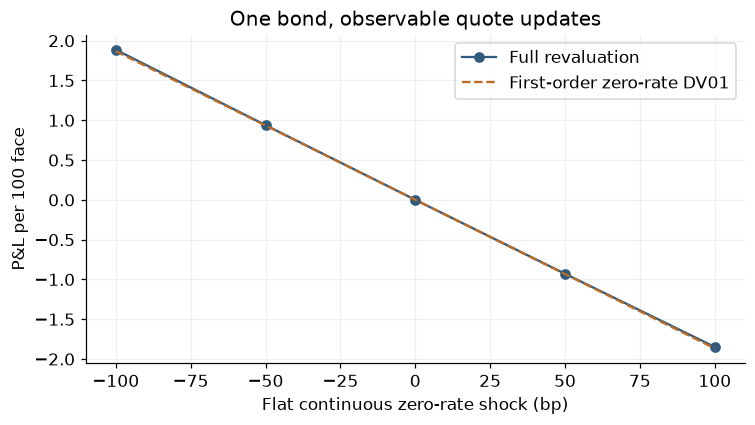

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(scenarios.zero_rate_shock_bp, scenarios.scenario_PnL, marker='o', label='Full revaluation', color='#315b7d')
ax.plot(scenarios.zero_rate_shock_bp, scenarios.zero_rate_shock_bp*signed_dv01,
        ls='--', label='First-order zero-rate DV01', color='#bc6c25')
ax.set(xlabel='Flat continuous zero-rate shock (bp)', ylabel='P&L per 100 face',
       title='One bond, observable quote updates')
ax.legend(); fig.tight_layout(); plt.show()

## Interpretation

Quote updates and curve relinking both propagate to the existing instrument. Every scenario matches direct discounting, the finite-difference sensitivity matches the derivative, and the original quote and link are restored.